In [2]:
import pandas as pd
from pathlib import Path

# Paths based on your current project structure
BASE_DIR = Path("..")  # from MVP folder, go back to project root

KNMI_PATH = BASE_DIR / "datasets" / "wind_data" / "KNMI_cleaned_mvp.csv"

ENERGY_FILES = [
    BASE_DIR / "datasets" / "wind_energy" / "wind-2017-uur-data-daily.csv",
    BASE_DIR / "datasets" / "wind_energy" / "wind-2018-uur-data-daily.csv",
    BASE_DIR / "datasets" / "wind_energy" / "wind-2019-uur-data-daily.csv",
    BASE_DIR / "datasets" / "wind_energy" / "wind-2020-uur-data-daily.csv",
    BASE_DIR / "datasets" / "wind_energy" / "wind-2021-uur-data-daily.csv",
]

OUTPUT_PATH = BASE_DIR / "MVP" / "merged_weather_energy_daily_mvp.csv"

# Load KNMI cleaned data
knmi = pd.read_csv(KNMI_PATH)
knmi["date"] = pd.to_datetime(knmi["date"])

# Aggregate all selected KNMI stations per day
daily_weather = knmi.groupby("date").agg(
    avg_wind_speed_all_stations=("avg_wind_speed_ms", "mean"),
    vector_avg_wind_speed_all_stations=("vector_avg_wind_speed_ms", "mean"),
    avg_wind_direction=("wind_direction_deg", "mean")
).reset_index()

# Wind-power proxy feature
daily_weather["avg_wind_speed_cubed"] = daily_weather["avg_wind_speed_all_stations"] ** 3

# Load and combine all daily wind energy files
energy = pd.concat(
    [pd.read_csv(file) for file in ENERGY_FILES],
    ignore_index=True
)

energy["date"] = pd.to_datetime(energy["date"])

# Rename column because after daily summing it is closer to generated energy, not fixed capacity
energy = energy.rename(columns={
    "capacity (kW)": "daily_wind_generation_kwh"
})

# Merge KNMI weather and wind energy data on date
merged = pd.merge(
    daily_weather,
    energy,
    on="date",
    how="inner"
)

# Save merged MVP dataset
merged.to_csv(OUTPUT_PATH, index=False)

print("Merged dataset saved to:", OUTPUT_PATH)
print("Rows:", len(merged))
print("Date range:", merged["date"].min(), "to", merged["date"].max())
print()
print(merged.head())

Merged dataset saved to: ..\MVP\merged_weather_energy_daily_mvp.csv
Rows: 1826
Date range: 2017-01-01 00:00:00 to 2021-12-31 00:00:00

        date  avg_wind_speed_all_stations  vector_avg_wind_speed_all_stations  \
0 2017-01-01                         7.76                                6.32   
1 2017-01-02                         6.96                                6.26   
2 2017-01-03                         9.74                                9.54   
3 2017-01-04                        11.16                               10.68   
4 2017-01-05                         5.12                                3.54   

   avg_wind_direction  avg_wind_speed_cubed  daily_wind_generation_kwh  
0               214.8            467.288576                   32234925  
1               327.0            337.153536                    9910909  
2               271.2            924.010424                   40292054  
3               324.8           1389.928896                   49113799  
4            

In [3]:
print("Missing values:")
print(merged.isna().sum())

print("\nCorrelation with daily wind generation:")
print(
    merged[
        [
            "avg_wind_speed_all_stations",
            "vector_avg_wind_speed_all_stations",
            "avg_wind_speed_cubed",
            "avg_wind_direction",
            "daily_wind_generation_kwh"
        ]
    ].corr()["daily_wind_generation_kwh"].sort_values(ascending=False)
)

Missing values:
date                                  0
avg_wind_speed_all_stations           0
vector_avg_wind_speed_all_stations    0
avg_wind_direction                    0
avg_wind_speed_cubed                  0
daily_wind_generation_kwh             0
dtype: int64

Correlation with daily wind generation:
daily_wind_generation_kwh             1.000000
avg_wind_speed_all_stations           0.933334
vector_avg_wind_speed_all_stations    0.904501
avg_wind_speed_cubed                  0.842140
avg_wind_direction                    0.166718
Name: daily_wind_generation_kwh, dtype: float64


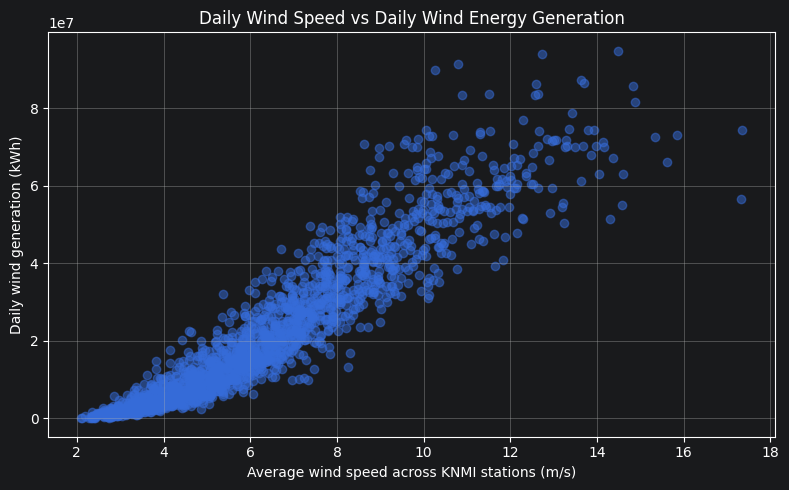

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    merged["avg_wind_speed_all_stations"],
    merged["daily_wind_generation_kwh"],
    alpha=0.5
)

plt.title("Daily Wind Speed vs Daily Wind Energy Generation")
plt.xlabel("Average wind speed across KNMI stations (m/s)")
plt.ylabel("Daily wind generation (kWh)")
plt.grid(True)
plt.tight_layout()
plt.show()

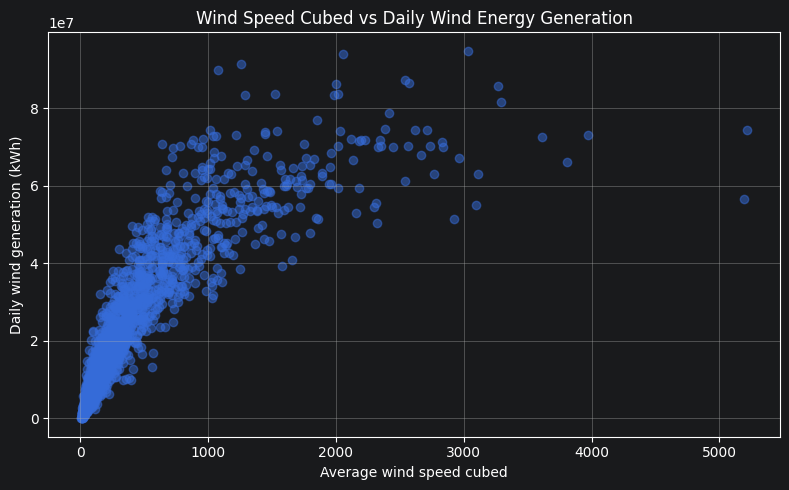

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    merged["avg_wind_speed_cubed"],
    merged["daily_wind_generation_kwh"],
    alpha=0.5
)

plt.title("Wind Speed Cubed vs Daily Wind Energy Generation")
plt.xlabel("Average wind speed cubed")
plt.ylabel("Daily wind generation (kWh)")
plt.grid(True)
plt.tight_layout()
plt.show()

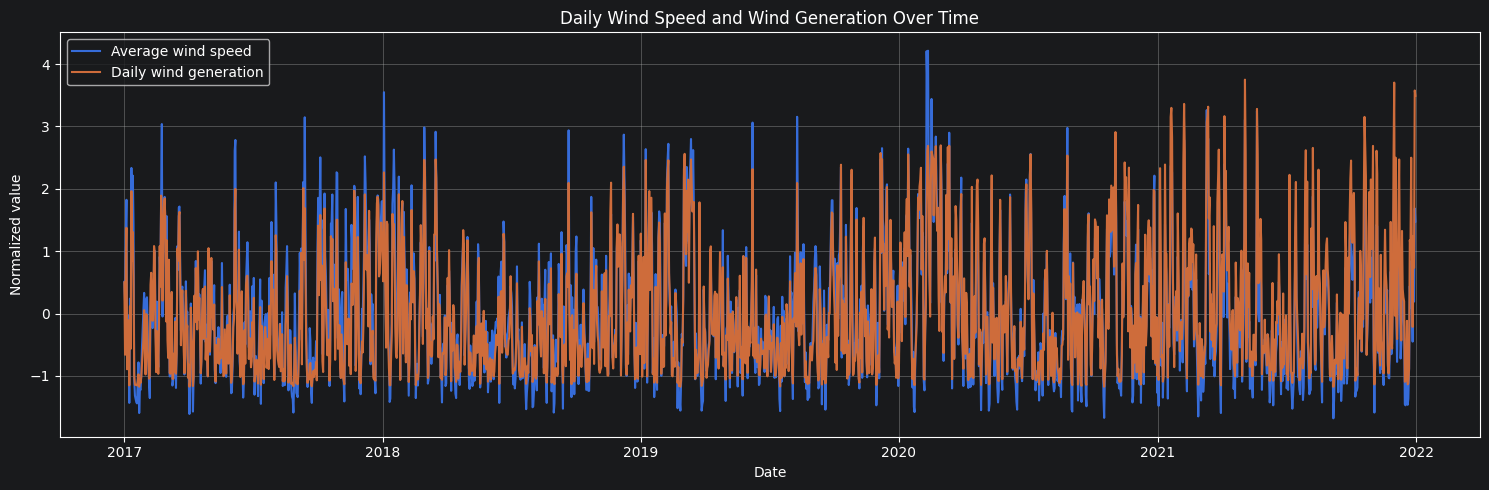

In [6]:
plot_df = merged.copy()

plot_df["wind_speed_normalized"] = (
    plot_df["avg_wind_speed_all_stations"] - plot_df["avg_wind_speed_all_stations"].mean()
) / plot_df["avg_wind_speed_all_stations"].std()

plot_df["generation_normalized"] = (
    plot_df["daily_wind_generation_kwh"] - plot_df["daily_wind_generation_kwh"].mean()
) / plot_df["daily_wind_generation_kwh"].std()

plt.figure(figsize=(15, 5))

plt.plot(
    plot_df["date"],
    plot_df["wind_speed_normalized"],
    label="Average wind speed"
)

plt.plot(
    plot_df["date"],
    plot_df["generation_normalized"],
    label="Daily wind generation"
)

plt.title("Daily Wind Speed and Wind Generation Over Time")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

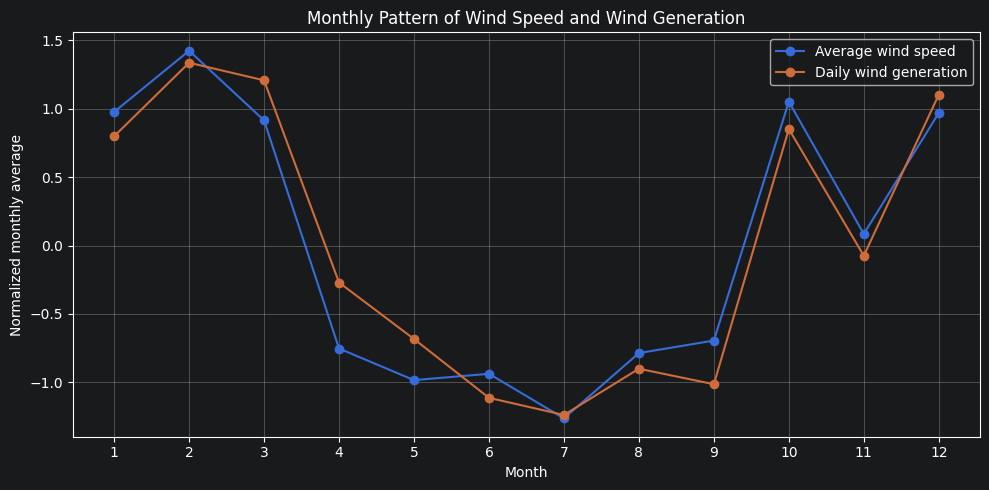

In [7]:
monthly = merged.copy()
monthly["month"] = monthly["date"].dt.month

monthly = monthly.groupby("month").agg(
    avg_wind_speed=("avg_wind_speed_all_stations", "mean"),
    avg_generation=("daily_wind_generation_kwh", "mean")
).reset_index()

monthly["wind_speed_normalized"] = (
    monthly["avg_wind_speed"] - monthly["avg_wind_speed"].mean()
) / monthly["avg_wind_speed"].std()

monthly["generation_normalized"] = (
    monthly["avg_generation"] - monthly["avg_generation"].mean()
) / monthly["avg_generation"].std()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly["month"],
    monthly["wind_speed_normalized"],
    marker="o",
    label="Average wind speed"
)

plt.plot(
    monthly["month"],
    monthly["generation_normalized"],
    marker="o",
    label="Daily wind generation"
)

plt.title("Monthly Pattern of Wind Speed and Wind Generation")
plt.xlabel("Month")
plt.ylabel("Normalized monthly average")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

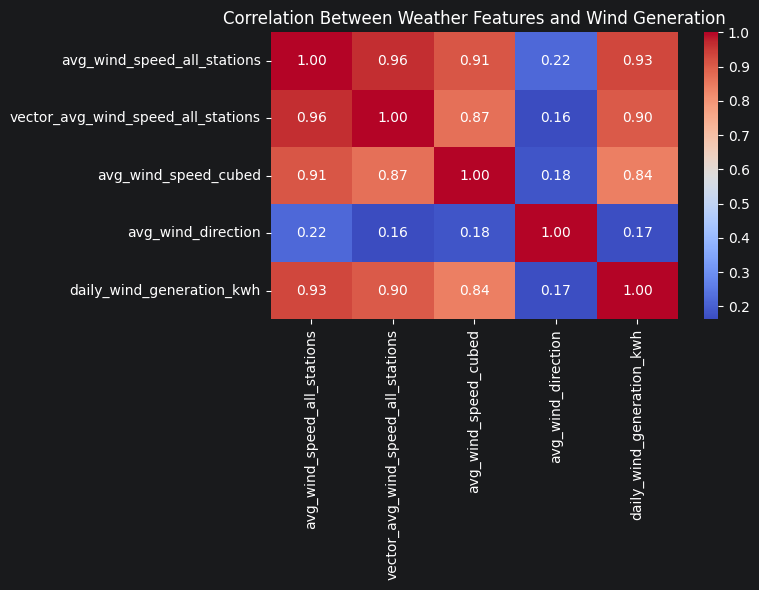

In [8]:
import seaborn as sns

corr_columns = [
    "avg_wind_speed_all_stations",
    "vector_avg_wind_speed_all_stations",
    "avg_wind_speed_cubed",
    "avg_wind_direction",
    "daily_wind_generation_kwh"
]

corr_matrix = merged[corr_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Weather Features and Wind Generation")
plt.tight_layout()
plt.show()